# COVID-19 in India — Exploring Case Trends, Recovery and Vaccination

**Objective:** Explore India's COVID-19 data to understand state-wise case patterns, compare recovery and fatality ratios, and examine vaccination progress using **NumPy, Pandas, Matplotlib and Seaborn**.

**Data sources:**

* **Case data:** `imdevskp/covid-19-india-data` — state-wise confirmed cases, recoveries and deaths from **30 January to 6 August 2020**.
* **Vaccination data:** **Our World in Data (OWID)** — national vaccination records covering **15 January 2021 to 12 August 2024** in the snapshot used.

**Workflow:** Load → Inspect → Clean → Calculate metrics → Analyse with groupby and pivot tables → Create 13 visualisations → Summarise findings.

> **Understanding the timeline:** The case dataset captures the early months of India's pandemic, ending before the vaccination rollout began. Vaccination records cover a separate, later period. These datasets are analysed independently to describe the outbreak and subsequent vaccination progress; they cannot establish vaccination effects on the earlier case trends.


## 1. Questions and analysis plan

1. How did reported national confirmed, recovered and death totals change?
2. Which states/UTs recorded the largest and smallest case totals on a common date?
3. How did recovery and reported case-fatality ratios vary?
4. What do state/month summaries reveal about the growth in reported counts?
5. How did national vaccine doses and fully vaccinated people increase later?
6. Which data-quality issues limit these comparisons?

The workflow is **load → inspect → clean → derive metrics → aggregate → visualise → interpret → export**. A row in the case file represents a state/UT on a reporting date. Counts such as confirmed cases are cumulative: summing them across dates would count the same cases repeatedly.

## 2. Environment and data sources

In [1]:
from pathlib import Path
from urllib.request import urlretrieve
from textwrap import fill
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="notebook")
COLORS = {"confirmed": "#5455A5", "recovered": "#168C88", "deaths": "#C95A67"}
plt.rcParams.update({"figure.dpi": 115, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.titleweight": "bold"})
pd.set_option("display.max_columns", 16)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
BASE = Path.cwd()
DATA = BASE / "data"
OUTPUT = BASE / "outputs"
FIGURES = OUTPUT / "figures"
for folder in (DATA, OUTPUT, FIGURES):
    folder.mkdir(parents=True, exist_ok=True)
observations = []

def observe(text):
    """Show a data-based finding and keep it for the written report."""
    observations.append(text)
    display(Markdown("**Observation.** " + text))

def finish(fig, name):
    fig.tight_layout()
    fig.savefig(FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def date_axis(ax):
    locator = mdates.AutoDateLocator(minticks=4, maxticks=10)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

def count_axis(ax, axis="y"):
    formatter = FuncFormatter(lambda number, _: f"{number:,.0f}")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(formatter)

print(f"Python {sys.version.split()[0]} | Pandas {pd.__version__} | NumPy {np.__version__}")

Python 3.12.14 | Pandas 2.2.3 | NumPy 2.3.5


### Historical sources and reproducibility

| File | Source | Role |
|---|---|---|
| `complete.csv` | [imdevskp/covid-19-india-data](https://github.com/imdevskp/covid-19-india-data), a compilation of Indian COVID-19 reporting | State/UT cumulative case, recovery and death counts |
| `India.csv` | [Our World in Data vaccination collection](https://github.com/owid/covid-19-data/tree/master/public/data/vaccinations), with row-level source links | National vaccine doses and vaccinated people |

The snapshots were retrieved on **24 September 2026**. That is the retrieval date, not the end of the observations. The actual coverage is calculated below. Source commits and file checksums are recorded in `data/source_metadata.json` in the full project.

`Cured/Discharged/Migrated` is labelled **recovered** for readability, but its broader source definition remains a limitation. Total doses and numbers of people are different units.

In [2]:
SOURCES = {'complete.csv': 'https://raw.githubusercontent.com/imdevskp/covid-19-india-data/ecfcd77a45aa1ae991896812e73a859badd45321/complete.csv', 'India.csv': 'https://raw.githubusercontent.com/owid/covid-19-data/dc00e7296b17ab5548092c9e388b6fac6751f095/public/data/vaccinations/country_data/India.csv'}

for filename, url in SOURCES.items():
    target = DATA / filename
    if not target.exists():
        urlretrieve(url, target)
        print("Downloaded:", filename)

raw_cases = pd.read_csv(DATA / "complete.csv")
raw_vax = pd.read_csv(DATA / "India.csv")
print("Cases:", raw_cases.shape, "| Vaccination:", raw_vax.shape)
display(raw_cases.head())
display(raw_vax.head())

Cases: (4692, 10) | Vaccination: (1250, 8)


,Date,Name of State / UT,Latitude,Longitude,Total Confirmed cases,Death,Cured/Discharged/Migrated,New cases,New deaths,New recovered
0,2020-01-30,Kerala,10.85,76.27,1.00,0,0.00,0,0,0
1,2020-01-31,Kerala,10.85,76.27,1.00,0,0.00,0,0,0
2,2020-02-01,Kerala,10.85,76.27,2.00,0,0.00,1,0,0
3,2020-02-02,Kerala,10.85,76.27,3.00,0,0.00,1,0,0
4,2020-02-03,Kerala,10.85,76.27,3.00,0,0.00,0,0,0


,location,date,vaccine,source_url,total_vaccinations,people_vaccinated,people_fully_vaccinated,total_boosters
0,India,2021-01-15,"Covaxin, Oxford/AstraZeneca",https://twitter.com/MoHFW_INDIA/status/1350459...,0,0.00,0.00,NaN
1,India,2021-01-16,"Covaxin, Oxford/AstraZeneca",https://twitter.com/MoHFW_INDIA/status/1350459...,191181,"191,181.00",0.00,NaN
2,India,2021-01-17,"Covaxin, Oxford/AstraZeneca",https://twitter.com/MoHFW_INDIA/status/1350815...,224301,"224,301.00",0.00,NaN
3,India,2021-01-18,"Covaxin, Oxford/AstraZeneca",https://www.mohfw.gov.in/,454049,"454,049.00",0.00,NaN
4,India,2021-01-19,"Covaxin, Oxford/AstraZeneca",https://www.mohfw.gov.in/,674835,"674,835.00",0.00,NaN


## 3. Inspect the raw files

Check types, missing values, state labels and duplicate rows before altering any data. A file can have no blank cells and still contain invalid numeric text.

In [3]:
def inspect_table(frame):
    return pd.DataFrame({"dtype": frame.dtypes.astype(str),
                         "missing": frame.isna().sum(),
                         "unique_values": frame.nunique()})

display(inspect_table(raw_cases))
display(inspect_table(raw_vax))
print("Exact duplicate rows:", raw_cases.duplicated().sum(), raw_vax.duplicated().sum())
print("Raw state labels:", raw_cases["Name of State / UT"].nunique())
print(sorted(raw_cases["Name of State / UT"].unique()))
non_numeric_deaths = pd.to_numeric(raw_cases["Death"], errors="coerce").isna()
display(raw_cases.loc[non_numeric_deaths, ["Date", "Name of State / UT", "Death"]])

Exact duplicate rows: 0 0
Raw state labels: 40
['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli and Daman and Diu', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Ladakh', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Telangana***', 'Telengana', 'Tripura', 'Union Territory of Chandigarh', 'Union Territory of Jammu and Kashmir', 'Union Territory of Ladakh', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


,dtype,missing,unique_values
Date,object,0,186
Name of State / UT,object,0,40
Latitude,float64,0,36
Longitude,float64,0,32
Total Confirmed cases,float64,0,2570
Death,object,0,839
Cured/Discharged/Migrated,float64,0,2143
New cases,int64,0,1058
New deaths,int64,0,1
New recovered,int64,0,901


,dtype,missing,unique_values
location,object,0,1
date,object,0,1250
vaccine,object,0,4
source_url,object,0,70
total_vaccinations,int64,0,1250
people_vaccinated,float64,5,1245
people_fully_vaccinated,float64,12,1209
total_boosters,float64,363,886


,Date,Name of State / UT,Death
2241,2020-05-24,Puducherry,0#


## 4. Clean and audit

- Rename columns by their names rather than their position.
- Strip whitespace, remove the `Union Territory of` prefix and standardise Telangana aliases.
- Remove the visible `#` footnote marker from the death field; convert numeric data without replacing unknown values with zero.
- Remove only exact duplicates. Conflicting state/date records stop execution rather than being silently discarded.
- Keep negative changes as quality flags: a reporting correction is not a negative infection count.
- Preserve missing vaccination values. Neither backward filling nor treating blanks as zero is appropriate here.

In [4]:
rename = {
    "Date": "date", "Name of State / UT": "state", "Latitude": "latitude",
    "Longitude": "longitude", "Total Confirmed cases": "confirmed", "Death": "deaths",
    "Cured/Discharged/Migrated": "recovered", "New cases": "source_new_cases",
    "New deaths": "source_new_deaths", "New recovered": "source_new_recovered"
}
assert set(rename).issubset(raw_cases.columns), "Unexpected case-file columns."
cases = raw_cases.rename(columns=rename).copy()
cases["date"] = pd.to_datetime(cases["date"], format="%Y-%m-%d", errors="coerce")
cases["state"] = (cases["state"].str.strip()
                  .str.replace(r"^Union Territory of\s+", "", regex=True)
                  .str.replace("*", "", regex=False).str.strip()
                  .replace({"Telengana": "Telangana"}))
for col in ["confirmed", "deaths", "recovered", "source_new_cases",
            "source_new_deaths", "source_new_recovered"]:
    text = cases[col].astype("string").str.replace("#", "", regex=False).str.strip()
    cases[col] = pd.to_numeric(text, errors="coerce").astype(float)

assert cases[["date", "state", "confirmed", "deaths", "recovered"]].notna().all().all(),     "Unresolved values require review; do not fill them with zero."
before = len(cases)
cases = cases.drop_duplicates().sort_values(["state", "date"]).reset_index(drop=True)
assert not cases.duplicated(["state", "date"]).any(), "Conflicting state/date records."
assert cases[["confirmed", "deaths", "recovered"]].ge(0).all().all()

cases["active"] = cases["confirmed"] - cases["recovered"] - cases["deaths"]
assert cases["active"].ge(0).all(), "Review inconsistent outcome totals."
denominator = cases["confirmed"].replace(0, np.nan)
cases["recovery_pct"] = 100 * cases["recovered"] / denominator
cases["fatality_pct"] = 100 * cases["deaths"] / denominator
cases["month"] = cases["date"].dt.strftime("%Y-%m")
cases["days_since_previous"] = cases.groupby("state")["date"].diff().dt.days
for col in ["confirmed", "recovered", "deaths"]:
    cases[f"change_{col}"] = cases.groupby("state")[col].diff()

changes = ["change_confirmed", "change_recovered", "change_deaths"]
revision_rows = cases.loc[cases[changes].lt(0).any(axis=1)]
missing_dates = pd.date_range(cases["date"].min(), cases["date"].max()).difference(cases["date"])
coverage = cases.groupby("date")["state"].nunique()
quality = pd.DataFrame({"check": ["Raw rows", "Exact duplicates removed", "Clean state/UT labels",
                                 "Observed dates", "Entirely missing dates", "Rows with a negative cumulative change"],
                        "value": [len(raw_cases), before-len(cases), cases["state"].nunique(),
                                  cases["date"].nunique(), len(missing_dates), len(revision_rows)]})
display(quality)
print("Missing calendar dates:", missing_dates.strftime("%Y-%m-%d").tolist())
display(revision_rows[["date", "state"] + changes])

Missing calendar dates: ['2020-06-26', '2020-07-01', '2020-07-04', '2020-07-06']


,check,value
0,Raw rows,4692
1,Exact duplicates removed,0
2,Clean state/UT labels,35
3,Observed dates,186
4,Entirely missing dates,4
5,Rows with a negative cumulative change,9


,date,state,change_confirmed,change_recovered,change_deaths
7,2020-04-02,Andaman and Nicobar Islands,0.00,-1.00,0.00
150,2020-04-01,Andhra Pradesh,43.00,-1.00,0.00
409,2020-04-14,Assam,-8.00,0.00,0.00
1040,2020-03-25,Delhi,1.00,0.00,-1.00
1892,2020-04-22,Jharkhand,-1.00,0.00,1.00
2629,2020-03-26,Maharashtra,-4.00,0.00,0.00
2775,2020-04-09,Manipur,-1.00,1.00,0.00
3406,2020-05-21,Puducherry,0.00,0.00,-1.00
4282,2020-03-15,Uttar Pradesh,1.00,-1.00,0.00


In [5]:
vax = raw_vax.copy()
vax["date"] = pd.to_datetime(vax["date"], format="%Y-%m-%d", errors="coerce")
vax_columns = ["total_vaccinations", "people_vaccinated", "people_fully_vaccinated", "total_boosters"]
for col in vax_columns:
    vax[col] = pd.to_numeric(vax[col], errors="coerce")
vax = vax.loc[vax["location"].eq("India")].drop_duplicates().sort_values("date").reset_index(drop=True)
assert vax["date"].notna().all() and not vax["date"].duplicated().any()
assert vax[vax_columns].dropna(how="all").ge(0).where(vax[vax_columns].notna(), True).all().all()
display(vax[vax_columns].isna().sum().rename("Missing values retained"))
print(f"Case coverage: {cases.date.min():%d %b %Y} to {cases.date.max():%d %b %Y}")
print(f"Vaccination coverage: {vax.date.min():%d %b %Y} to {vax.date.max():%d %b %Y}")

Case coverage: 30 Jan 2020 to 06 Aug 2020
Vaccination coverage: 15 Jan 2021 to 12 Aug 2024


total_vaccinations           0
people_vaccinated            5
people_fully_vaccinated     12
total_boosters             363
Name: Missing values retained, dtype: int64

### Definitions used throughout

| Metric | Calculation | Interpretation |
|---|---|---|
| Active | Confirmed − recovered − deaths | Residual from the source's cumulative categories |
| Recovery percentage | 100 × recovered / confirmed | Snapshot ratio, not a recovery probability for a patient |
| Reported case-fatality percentage | 100 × deaths / confirmed | Crude cumulative ratio, not infection-fatality risk |
| Daily reported change | Today's national total − yesterday's total | Used only on consecutive dates with the same reporting states and no negative confirmed corrections |

The word **national** below means the sum of states/UTs present in this source on that date. Early reporting coverage varies. We do not manufacture records for missing states, dates or Lakshadweep. Counts are not population-adjusted, so a low total alone does not establish a lower risk.

## 5. National totals with reporting-coverage checks

In [6]:
metrics = ["confirmed", "recovered", "deaths", "active"]
national = cases.groupby("date")[metrics].sum(min_count=1)
national["reporting_states"] = coverage
national["recovery_pct"] = 100 * national["recovered"] / national["confirmed"].replace(0, np.nan)
national["fatality_pct"] = 100 * national["deaths"] / national["confirmed"].replace(0, np.nan)
state_sets = cases.groupby("date")["state"].agg(frozenset)
national["same_states"] = state_sets.eq(state_sets.shift())
national["consecutive_date"] = national.index.to_series().diff().dt.days.eq(1)
national["raw_change"] = national["confirmed"].diff()
negative_confirmed_dates = cases.loc[cases["change_confirmed"].lt(0), "date"]
national["confirmed_revision"] = national.index.isin(negative_confirmed_dates)
national["comparable_day"] = (national["same_states"] & national["consecutive_date"]
                              & ~national["confirmed_revision"] & national["raw_change"].ge(0))
national["daily_change"] = national["raw_change"].where(national["comparable_day"])
# Keep absent calendar dates as NaN so lines break across missing observations.
daily = national.reindex(pd.date_range(national.index.min(), national.index.max(), name="date"))
daily["mean_7d"] = daily["daily_change"].rolling(7, min_periods=7).mean()
daily["month"] = daily.index.strftime("%Y-%m")
latest_date = cases["date"].max()
last = national.loc[latest_date]
display(national.tail())
display(pd.DataFrame({"metric": metrics + ["recovery_pct", "fatality_pct"],
                     "latest_value": [last[m] for m in metrics + ["recovery_pct", "fatality_pct"]]}))
print("Valid comparable one-day changes:", int(national.comparable_day.sum()))
print("Excluded date-to-date changes (excluding the first row):", int((~national.comparable_day).iloc[1:].sum()))

Valid comparable one-day changes: 153
Excluded date-to-date changes (excluding the first row): 32


,confirmed,recovered,deaths,active,reporting_states,recovery_pct,fatality_pct,same_states,consecutive_date,raw_change,confirmed_revision,comparable_day,daily_change
date,,,,,,,,,,,,,
2020-08-02,"1,750,723.00","1,145,629.00","37,364.00","567,730.00",35,65.44,2.13,True,True,"54,735.00",False,True,"54,735.00"
2020-08-03,"1,803,695.00","1,186,203.00","38,135.00","579,357.00",35,65.77,2.11,True,True,"52,972.00",False,True,"52,972.00"
2020-08-04,"1,855,745.00","1,230,509.00","38,938.00","586,298.00",35,66.31,2.10,True,True,"52,050.00",False,True,"52,050.00"
2020-08-05,"1,908,254.00","1,282,215.00","39,795.00","586,244.00",35,67.19,2.09,True,True,"52,509.00",False,True,"52,509.00"
2020-08-06,"1,964,536.00","1,328,336.00","40,699.00","595,501.00",35,67.62,2.07,True,True,"56,282.00",False,True,"56,282.00"


,metric,latest_value
0,confirmed,"1,964,536.00"
1,recovered,"1,328,336.00"
2,deaths,"40,699.00"
3,active,"595,501.00"
4,recovery_pct,67.62
5,fatality_pct,2.07


In [7]:
# Investigate the largest apparent increase before calling it a daily peak.
jump_date = national["raw_change"].idxmax()
previous_date = national.index[national.index.get_loc(jump_date) - 1]
added = sorted(state_sets.loc[jump_date] - state_sets.loc[previous_date])
removed = sorted(state_sets.loc[previous_date] - state_sets.loc[jump_date])
observe(f"The largest unfiltered increase is {national.loc[jump_date, 'raw_change']:,.0f} on "
        f"{jump_date:%d %b %Y}. Reporting states changed from "
        f"{national.loc[previous_date, 'reporting_states']:.0f} to {national.loc[jump_date, 'reporting_states']:.0f}; "
        f"added: {', '.join(added) or 'none'}; removed: {', '.join(removed) or 'none'}. "
        "This is not a reliable single-day infection peak, so it is excluded from the daily-change charts.")

**Observation.** The largest unfiltered increase is 106,421 on 28 Jul 2020. Reporting states changed from 34 to 35; added: West Bengal; removed: none. This is not a reliable single-day infection peak, so it is excluded from the daily-change charts.

## 6. State snapshot and monthly pivot

Every ranked state comes from the same latest reporting date. For the pivot, use the last observed cumulative count per state/month—not a sum of cumulative counts. The final month is incomplete.

In [8]:
latest = cases.loc[cases["date"].eq(latest_date)].sort_values("confirmed", ascending=False).copy()
top10 = latest.head(10)
top5_names = latest.head(5)["state"].tolist()
bottom10 = latest.loc[latest.confirmed.gt(0)].nsmallest(10, "confirmed")
display(top10[["state", "confirmed", "active", "recovered", "deaths", "recovery_pct", "fatality_pct"]])
month_pivot = (cases.loc[cases.state.isin(top5_names)].sort_values("date")
               .pivot_table(index="state", columns="month", values="confirmed", aggfunc="last")
               .reindex(top5_names))
month_last_dates = (cases.loc[cases.state.isin(top5_names)].sort_values("date")
                    .groupby(["state", "month"])["date"].last().unstack())
display(month_pivot)
print("Dates behind the latest monthly column:")
display(month_last_dates.iloc[:, -1])

Dates behind the latest monthly column:


,state,confirmed,active,recovered,deaths,recovery_pct,fatality_pct
2758,Maharashtra,"468,265.00","146,268.00","305,521.00","16,476.00",65.25,3.52
3998,Tamil Nadu,"273,460.00","54,184.00","214,815.00","4,461.00",78.55,1.63
273,Andhra Pradesh,"186,461.00","80,426.00","104,354.00","1,681.00",55.97,0.90
2141,Karnataka,"151,449.00","73,966.00","74,679.00","2,804.00",49.31,1.85
1170,Delhi,"140,232.00","10,072.00","126,116.00","4,044.00",89.93,2.88
4422,Uttar Pradesh,"104,388.00","41,973.00","60,558.00","1,857.00",58.01,1.78
4691,West Bengal,"83,800.00","22,992.00","58,962.00","1,846.00",70.36,2.20
4152,Telangana,"73,050.00","20,358.00","52,103.00",589.00,71.33,0.81
1436,Gujarat,"66,669.00","14,680.00","49,433.00","2,556.00",74.15,3.83
653,Bihar,"64,770.00","22,001.00","42,414.00",355.00,65.48,0.55


month,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08
state,,,,,,
Maharashtra,216.00,"9,915.00","65,168.00","169,883.00","411,798.00","468,265.00"
Tamil Nadu,74.00,"2,162.00","21,184.00","86,224.00","239,978.00","273,460.00"
Andhra Pradesh,40.00,"1,332.00","3,569.00","13,891.00","130,557.00","186,461.00"
Karnataka,83.00,535.00,"2,922.00","14,295.00","118,632.00","151,449.00"
Delhi,97.00,"3,439.00","18,549.00","85,161.00","134,403.00","140,232.00"


state
Andhra Pradesh   2020-08-06
Delhi            2020-08-06
Karnataka        2020-08-06
Maharashtra      2020-08-06
Tamil Nadu       2020-08-06
Name: 2020-08, dtype: datetime64[ns]

## 7. Visual analysis

Each chart answers a specific question. Counts and rates are kept separate, and observations are generated from the actual DataFrames so they remain tied to the calculations.

### 01 · The early national trajectory

How did the three cumulative measures change across the case window?

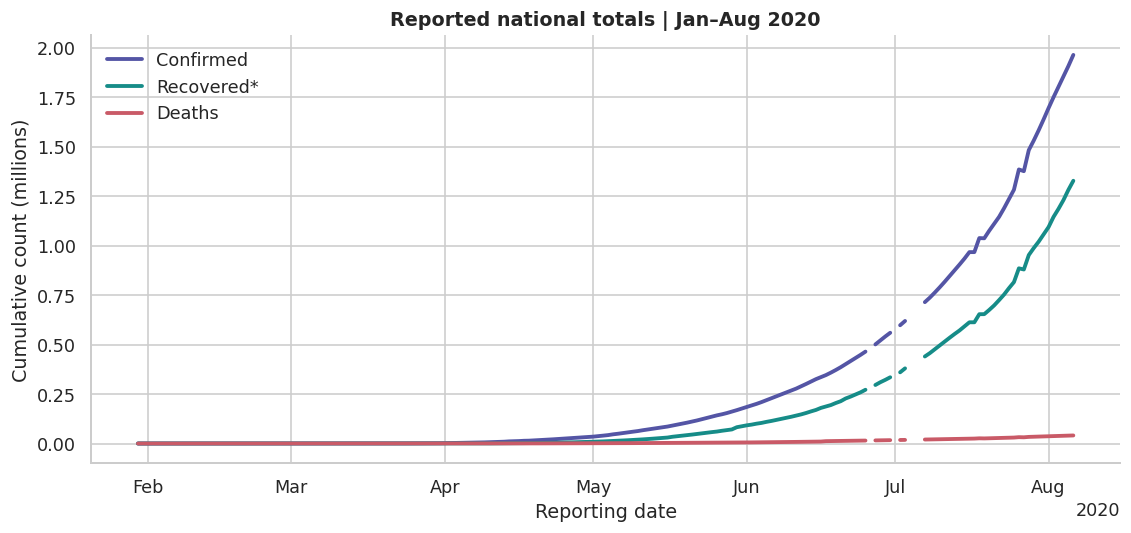

In [9]:
fig, ax = plt.subplots(figsize=(10, 4.8))
for metric, label in [("confirmed", "Confirmed"), ("recovered", "Recovered*"), ("deaths", "Deaths")]:
    ax.plot(daily.index, daily[metric] / 1e6, label=label, color=COLORS[metric], linewidth=2.4)
ax.set(title="Reported national totals | Jan–Aug 2020", xlabel="Reporting date", ylabel="Cumulative count (millions)")
ax.legend(frameon=False)
date_axis(ax)
finish(fig, "01_national_totals")

In [10]:
observe(f"On {latest_date:%d %b %Y}, the reporting states total {last.confirmed:,.0f} confirmed cases, "
        f"{last.recovered:,.0f} recovered/discharged/migrated records and {last.deaths:,.0f} deaths. "
        "The gap between confirmed cases and the two resolved categories is the active residual. Coverage changes can also affect this series.")

**Observation.** On 06 Aug 2020, the reporting states total 1,964,536 confirmed cases, 1,328,336 recovered/discharged/migrated records and 40,699 deaths. The gap between confirmed cases and the two resolved categories is the active residual. Coverage changes can also affect this series.

### 02 · Daily change, with unreliable comparisons removed

Are increases still large near the end of the window? Missing or excluded days remain gaps.

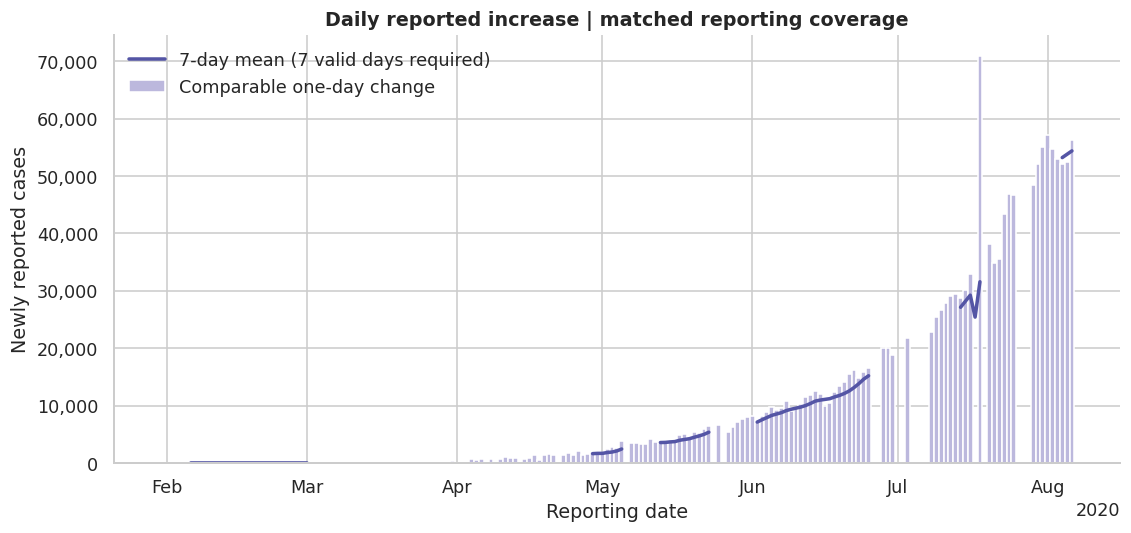

In [11]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(daily.index, daily["daily_change"], width=1, color="#BCB8DD", label="Comparable one-day change")
ax.plot(daily.index, daily["mean_7d"], color="#5455A5", lw=2.2, label="7-day mean (7 valid days required)")
ax.set(title="Daily reported increase | matched reporting coverage", xlabel="Reporting date", ylabel="Newly reported cases")
ax.legend(frameon=False, loc="upper left")
date_axis(ax); count_axis(ax)
finish(fig, "02_daily_change")
valid_peak_date = daily["daily_change"].idxmax()

In [12]:
observe(f"The largest retained one-day increase is {daily.loc[valid_peak_date, 'daily_change']:,.0f} on "
        f"{valid_peak_date:%d %b %Y}. The final available day adds {last.daily_change:,.0f}. "
        "These are reporting changes after basic checks, not independently verified infection dates; the short window does not establish the full first-wave peak.")

**Observation.** The largest retained one-day increase is 70,962 on 18 Jul 2020. The final available day adds 56,282. These are reporting changes after basic checks, not independently verified infection dates; the short window does not establish the full first-wave peak.

### 03 · States with the largest confirmed totals

Which states/UTs have the greatest absolute counts on the common snapshot date?

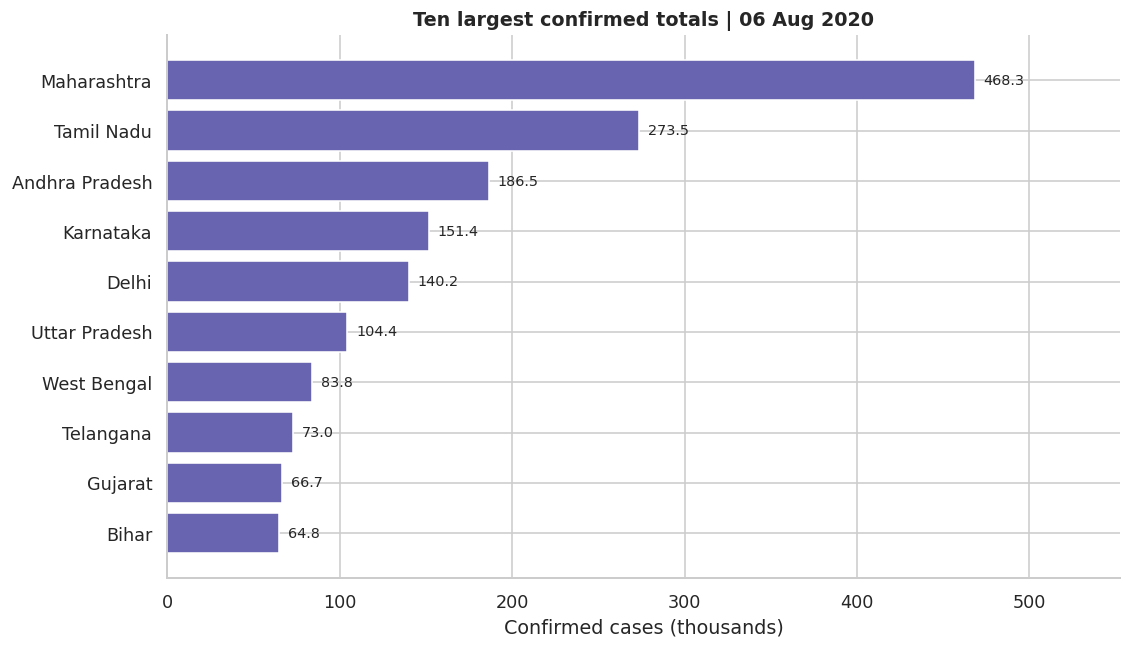

In [13]:
fig, ax = plt.subplots(figsize=(10, 5.8))
view = top10.sort_values("confirmed")
ax.barh(view.state, view.confirmed / 1000, color="#6964AF")
for y, number in enumerate(view.confirmed):
    ax.text(number / 1000 + 5, y, f"{number/1000:,.1f}", va="center", fontsize=9)
ax.set(xlim=(0, view.confirmed.max()/1000*1.18), xlabel="Confirmed cases (thousands)", ylabel="",
       title=f"Ten largest confirmed totals | {latest_date:%d %b %Y}")
finish(fig, "03_top_states")
leader = latest.iloc[0]

In [14]:
observe(f"{leader.state} has the largest count ({leader.confirmed:,.0f}), followed by {latest.iloc[1].state} "
        f"({latest.iloc[1].confirmed:,.0f}). These are absolute counts; population size and testing coverage are not controlled for.")

**Observation.** Maharashtra has the largest count (468,265), followed by Tamil Nadu (273,460). These are absolute counts; population size and testing coverage are not controlled for.

### 04 · Recovery ratios among high-count states

How much of each cumulative confirmed total is recorded as recovered?

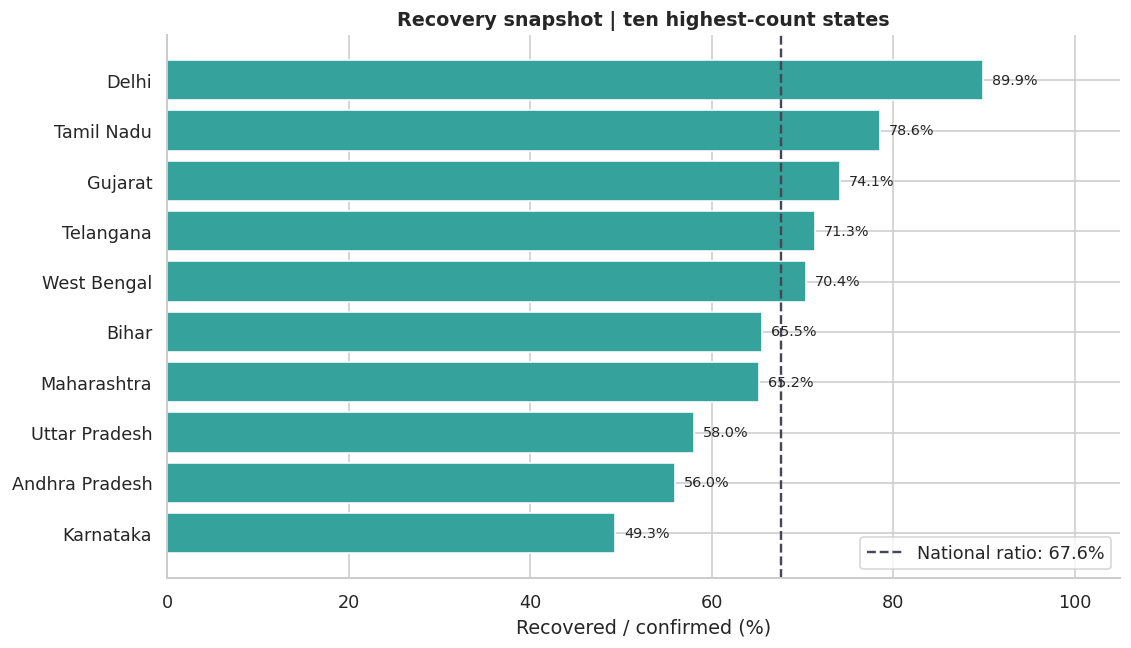

In [15]:
view = top10.sort_values("recovery_pct")
fig, ax = plt.subplots(figsize=(10, 5.8))
ax.barh(view.state, view.recovery_pct, color="#36A29C")
ax.axvline(last.recovery_pct, color="#484554", linestyle="--", label=f"National ratio: {last.recovery_pct:.1f}%")
for y, number in enumerate(view.recovery_pct):
    ax.text(number + 1, y, f"{number:.1f}%", va="center", fontsize=9)
ax.set(xlim=(0, 105), xlabel="Recovered / confirmed (%)", ylabel="", title="Recovery snapshot | ten highest-count states")
ax.legend(loc="lower right", frameon=True)
finish(fig, "04_recovery_comparison")
best_recovery = top10.loc[top10.recovery_pct.idxmax()]
lowest_recovery = top10.loc[top10.recovery_pct.idxmin()]

In [16]:
observe(f"Within this group, {best_recovery.state} has the highest recovery ratio ({best_recovery.recovery_pct:.1f}%), "
        f"while {lowest_recovery.state} has the lowest ({lowest_recovery.recovery_pct:.1f}%). "
        "Differences in outbreak timing, reporting and unresolved cases prevent interpreting this as a ranking of treatment quality.")

**Observation.** Within this group, Delhi has the highest recovery ratio (89.9%), while Karnataka has the lowest (49.3%). Differences in outbreak timing, reporting and unresolved cases prevent interpreting this as a ranking of treatment quality.

### 05 · Growth in the five largest states

How did the states selected by their final totals develop over time?

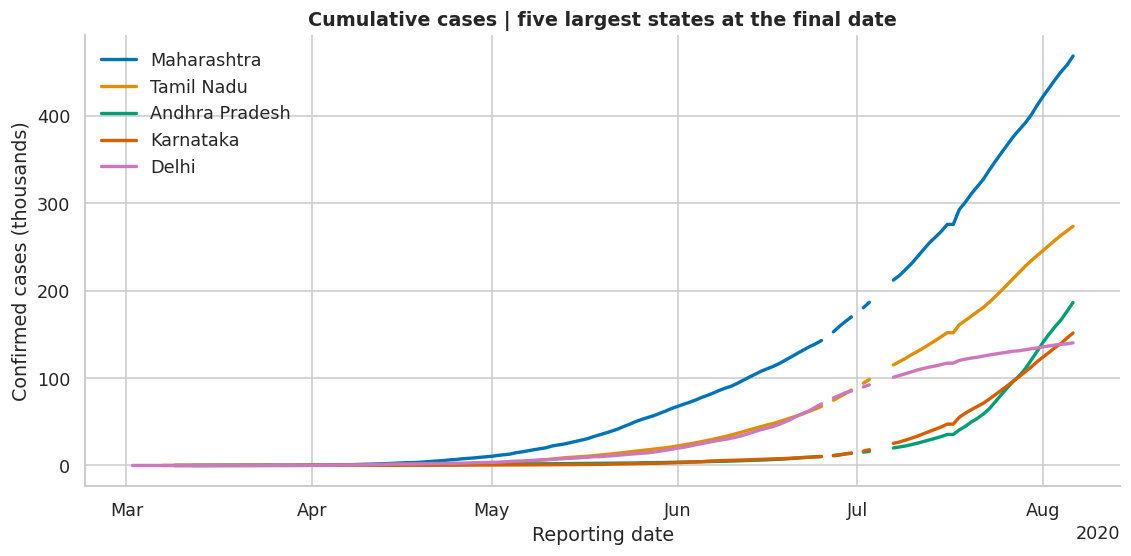

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
for state, color in zip(top5_names, sns.color_palette("colorblind", 5)):
    series = cases.loc[cases.state.eq(state)].set_index("date")["confirmed"].reindex(daily.index)
    ax.plot(series.index, series/1000, label=state, color=color, lw=2.1)
ax.set(title="Cumulative cases | five largest states at the final date", xlabel="Reporting date", ylabel="Confirmed cases (thousands)")
ax.legend(frameon=False); date_axis(ax)
finish(fig, "05_top_state_trends")

In [18]:
observe(f"The final-date top five are {', '.join(top5_names)}. "
        f"{leader.state} finishes at {leader.confirmed/latest.iloc[1].confirmed:.2f} times the second-ranked state's total. "
        "Selection is based on the final date, so this is not a fixed ranking for the entire period.")

**Observation.** The final-date top five are Maharashtra, Tamil Nadu, Andhra Pradesh, Karnataka, Delhi. Maharashtra finishes at 1.71 times the second-ranked state's total. Selection is based on the final date, so this is not a fixed ranking for the entire period.

### 06 · Concentration of reported cases

What share of the snapshot is concentrated in the largest states?

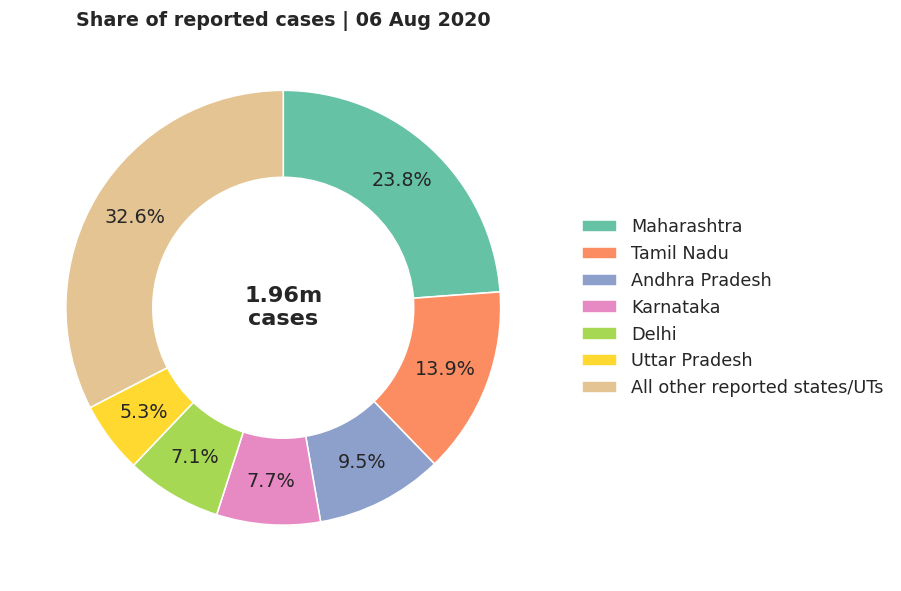

In [19]:
shares = latest.head(6).set_index("state")["confirmed"]
shares.loc["All other reported states/UTs"] = latest.confirmed.sum() - shares.sum()
fig, ax = plt.subplots(figsize=(10, 5.3))
wedges, _, _ = ax.pie(shares, startangle=90, counterclock=False, autopct="%1.1f%%", pctdistance=.80,
                      colors=sns.color_palette("Set2", len(shares)), wedgeprops={"width": .40, "edgecolor": "white"})
ax.text(0, 0, f"{last.confirmed/1e6:.2f}m\ncases", ha="center", va="center", fontsize=14, weight="bold")
ax.legend(wedges, shares.index, loc="center left", bbox_to_anchor=(1.02, .5), frameon=False)
ax.set_title(f"Share of reported cases | {latest_date:%d %b %Y}")
finish(fig, "06_case_shares")
top6_share = latest.head(6).confirmed.sum()/latest.confirmed.sum()*100

In [20]:
observe(f"The top six states account for {top6_share:.1f}% of all cases in the snapshot. "
        f"{leader.state} alone contributes {leader.confirmed/last.confirmed*100:.1f}%. "
        "This describes concentration of reported totals, not per-person infection risk.")

**Observation.** The top six states account for 67.4% of all cases in the snapshot. Maharashtra alone contributes 23.8%. This describes concentration of reported totals, not per-person infection risk.

### 07 · The national recovery ratio

How does the cumulative recovered share change during the case window?

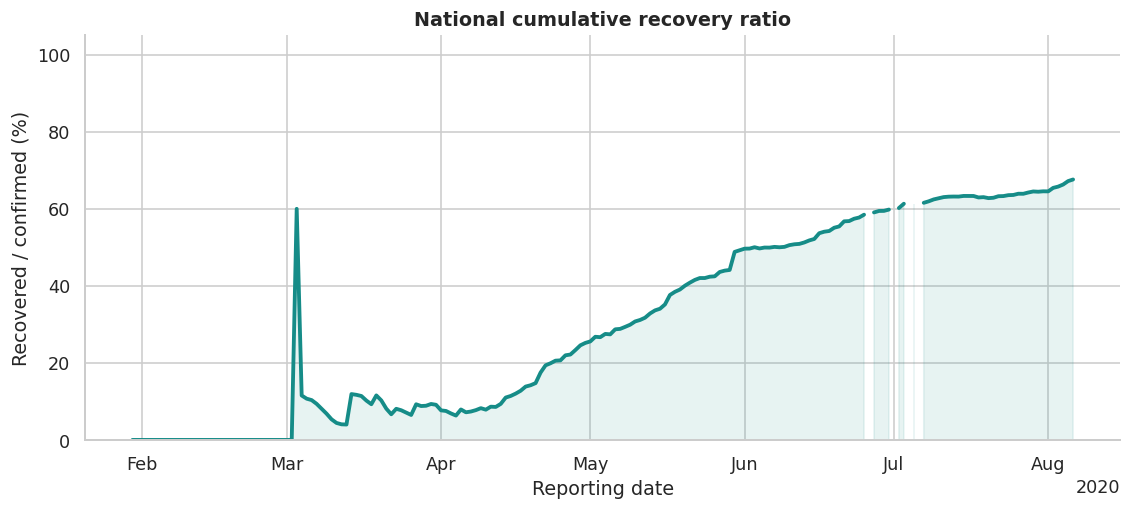

In [21]:
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.plot(daily.index, daily.recovery_pct, color="#168C88", lw=2.4)
ax.fill_between(daily.index, daily.recovery_pct, color="#168C88", alpha=.10)
ax.set(title="National cumulative recovery ratio", xlabel="Reporting date", ylabel="Recovered / confirmed (%)", ylim=(0, 105))
date_axis(ax)
finish(fig, "07_recovery_trend")

In [22]:
observe(f"The recovery ratio ends at {last.recovery_pct:.2f}%. "
        "Early ratios are unstable because the denominator is very small. A ratio can decrease even while recoveries increase if new confirmed totals rise faster.")

**Observation.** The recovery ratio ends at 67.62%. Early ratios are unstable because the denominator is very small. A ratio can decrease even while recoveries increase if new confirmed totals rise faster.

### 08 · Recovery and fatality ratios together

How do the two snapshot ratios differ among states with at least 1,000 confirmed cases?

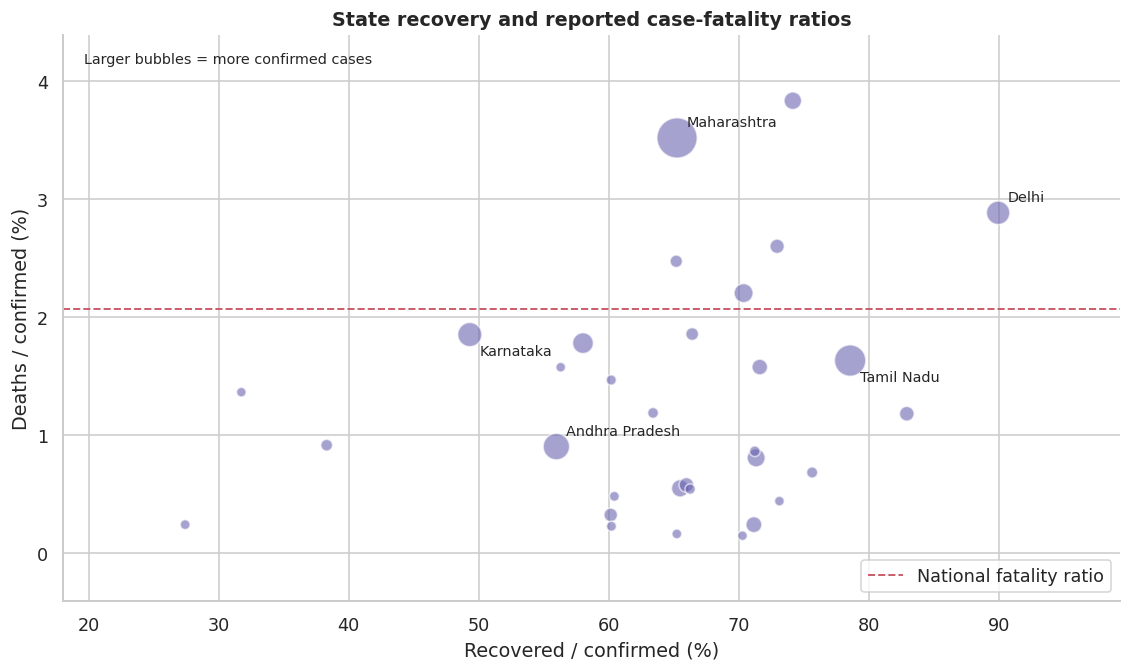

In [23]:
view = latest.loc[latest.confirmed.ge(1000)]
fig, ax = plt.subplots(figsize=(10, 6))
sizes = 35 + 600 * view.confirmed / view.confirmed.max()
ax.scatter(view.recovery_pct, view.fatality_pct, s=sizes, color="#6964AF", alpha=.6, edgecolors="white")
for i, (_, row) in enumerate(view.nlargest(5, "confirmed").iterrows()):
    ax.annotate(row.state, (row.recovery_pct, row.fatality_pct), xytext=(6, 7 if i%2==0 else -13),
                textcoords="offset points", fontsize=9)
ax.axhline(last.fatality_pct, color="#C95A67", ls="--", lw=1.2, label="National fatality ratio")
ax.set(title="State recovery and reported case-fatality ratios", xlabel="Recovered / confirmed (%)",
       ylabel="Deaths / confirmed (%)")
ax.text(.02, .97, "Larger bubbles = more confirmed cases", transform=ax.transAxes, va="top", fontsize=9)
ax.legend(loc="lower right"); ax.margins(.15)
finish(fig, "08_rate_relationship")
highest_fatality = view.loc[view.fatality_pct.idxmax()]

In [24]:
observe(f"Among states meeting the 1,000-case threshold, {highest_fatality.state} has the highest reported "
        f"case-fatality ratio ({highest_fatality.fatality_pct:.2f}%). The national ratio is {last.fatality_pct:.2f}%. "
        "Neither ratio adjusts for age, testing or the lag from diagnosis to outcome.")

**Observation.** Among states meeting the 1,000-case threshold, Gujarat has the highest reported case-fatality ratio (3.83%). The national ratio is 2.07%. Neither ratio adjusts for age, testing or the lag from diagnosis to outcome.

### 09 · Relationships among national metrics

Which quantities move together in the observed national time series?

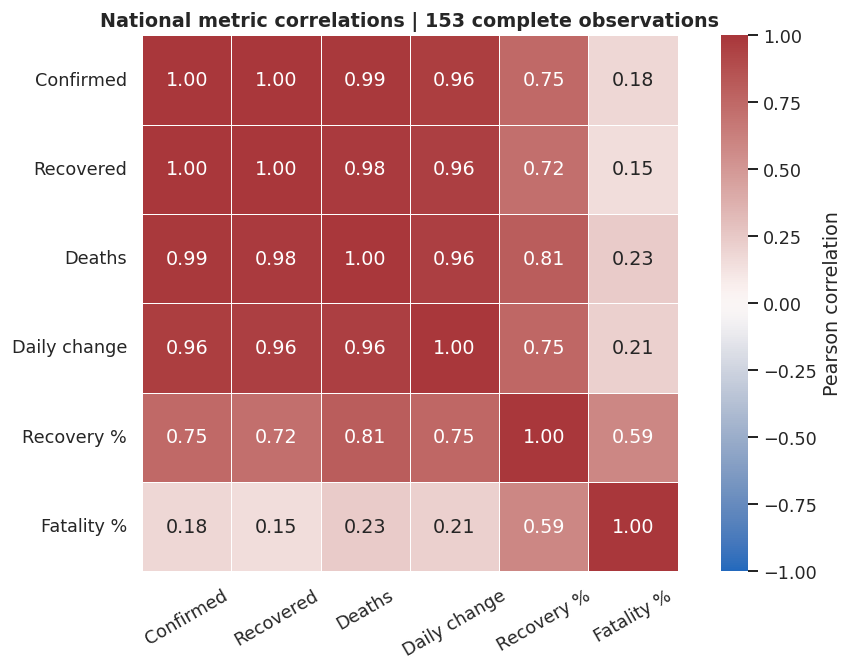

In [25]:
corr_names = {"confirmed": "Confirmed", "recovered": "Recovered", "deaths": "Deaths",
              "daily_change": "Daily change", "recovery_pct": "Recovery %", "fatality_pct": "Fatality %"}
# A common complete-case sample makes all displayed correlations comparable.
corr_input = national[list(corr_names)].dropna()
correlations = corr_input.rename(columns=corr_names).corr()
fig, ax = plt.subplots(figsize=(8.5, 6))
sns.heatmap(correlations, annot=True, fmt=".2f", vmin=-1, vmax=1, center=0, cmap="vlag", square=True,
            linewidths=.6, cbar_kws={"label": "Pearson correlation"}, ax=ax)
ax.set_title(f"National metric correlations | {len(corr_input)} complete observations")
ax.tick_params(axis="x", rotation=30)
finish(fig, "09_correlations")

In [26]:
observe(f"Confirmed and recovered totals have a Pearson correlation of {correlations.loc['Confirmed', 'Recovered']:.3f} "
        f"across {len(corr_input)} complete observations. Shared cumulative growth and common denominators can generate strong correlations. "
        "The heatmap is descriptive and does not identify causal effects.")

**Observation.** Confirmed and recovered totals have a Pearson correlation of 0.999 across 153 complete observations. Shared cumulative growth and common denominators can generate strong correlations. The heatmap is descriptive and does not identify causal effects.

### 10 · Distribution of daily changes by month

Does the typical retained daily increase become larger over successive months?

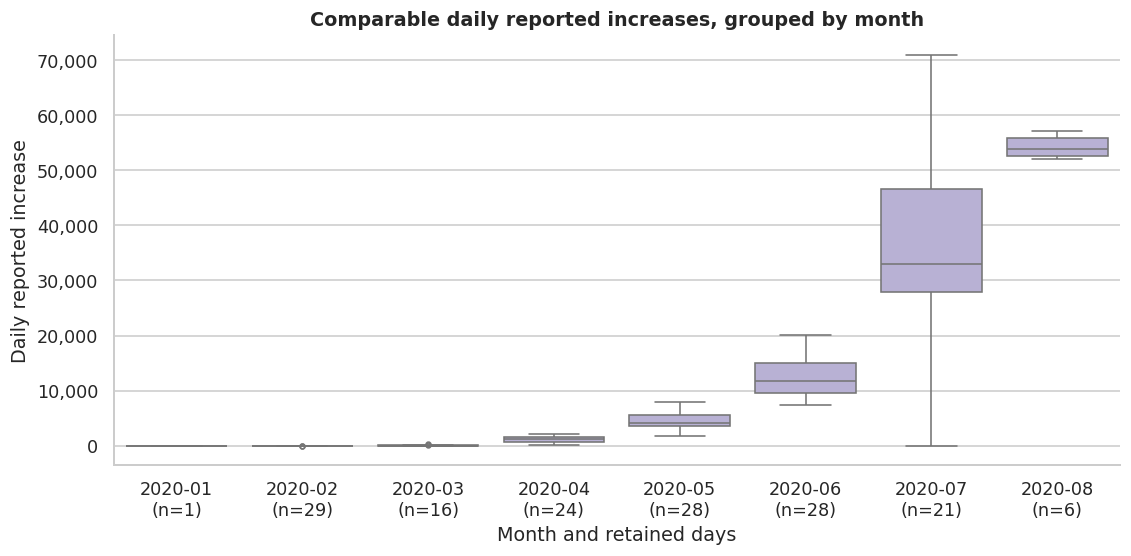

In [27]:
box_data = daily.dropna(subset=["daily_change"]).reset_index()
months = sorted(box_data.month.unique())
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=box_data, x="month", y="daily_change", order=months, color="#B4ABDA", ax=ax,
            fliersize=3, linewidth=1)
counts = box_data.groupby("month").size()
ax.set_xticks(range(len(months)), [f"{month}\n(n={counts[month]})" for month in months])
ax.set(title="Comparable daily reported increases, grouped by month", xlabel="Month and retained days", ylabel="Daily reported increase")
count_axis(ax)
finish(fig, "10_monthly_distribution")
monthly_medians = box_data.groupby("month")["daily_change"].median()

In [28]:
observe(f"The median retained daily change in July is {monthly_medians.loc['2020-07']:,.0f}, "
        f"compared with {monthly_medians.loc['2020-06']:,.0f} in June. "
        "Month sample sizes differ because of missing and excluded observations. August contains only the first six days, so its box is not a full-month summary.")

**Observation.** The median retained daily change in July is 32,934, compared with 11,680 in June. Month sample sizes differ because of missing and excluded observations. August contains only the first six days, so its box is not a full-month summary.

### 11 · Vaccination in a separate, later window

How do administered doses and fully vaccinated people progress? The two measures have separate axes because their units differ.

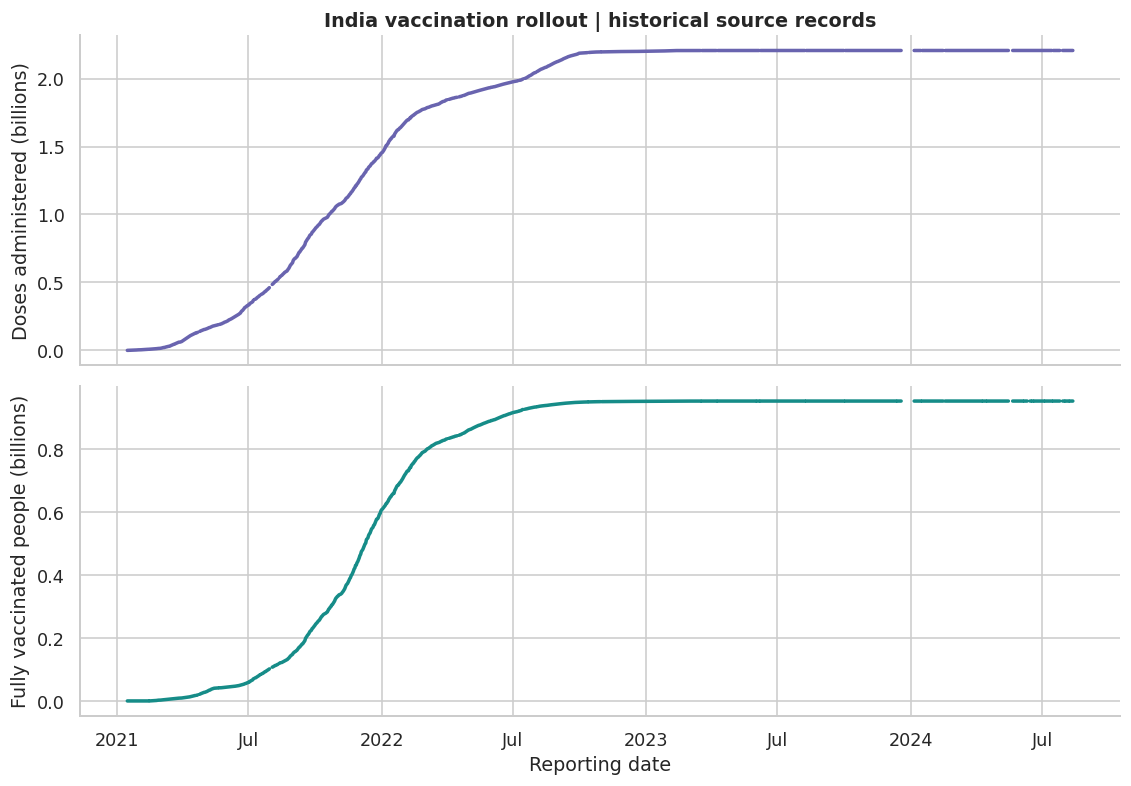

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
calendar = pd.date_range(vax.date.min(), vax.date.max())
vax_daily = vax.set_index("date").reindex(calendar)
axes[0].plot(calendar, vax_daily.total_vaccinations/1e9, color="#6964AF", lw=2.2)
axes[0].set(title="India vaccination rollout | historical source records", ylabel="Doses administered (billions)")
axes[1].plot(calendar, vax_daily.people_fully_vaccinated/1e9, color="#168C88", lw=2.2)
axes[1].set(ylabel="Fully vaccinated people (billions)", xlabel="Reporting date")
date_axis(axes[1])
finish(fig, "11_vaccination")
last_doses = vax.dropna(subset=["total_vaccinations"]).iloc[-1]
last_fully = vax.dropna(subset=["people_fully_vaccinated"]).iloc[-1]

In [30]:
observe(f"The source records {last_doses.total_vaccinations/1e9:.3f} billion doses as of {last_doses.date:%d %b %Y}, "
        f"and {last_fully.people_fully_vaccinated/1e6:.1f} million fully vaccinated people as of {last_fully.date:%d %b %Y}. "
        "Doses can exceed the number of people because one person can receive multiple doses. This later series cannot demonstrate an effect on the 2020 case window.")

**Observation.** The source records 2.207 billion doses as of 12 Aug 2024, and 952.0 million fully vaccinated people as of 12 Aug 2024. Doses can exceed the number of people because one person can receive multiple doses. This later series cannot demonstrate an effect on the 2020 case window.

### 12 · Smallest positive state/UT totals

Which reported states/UTs have the lowest absolute confirmed counts on the snapshot date?

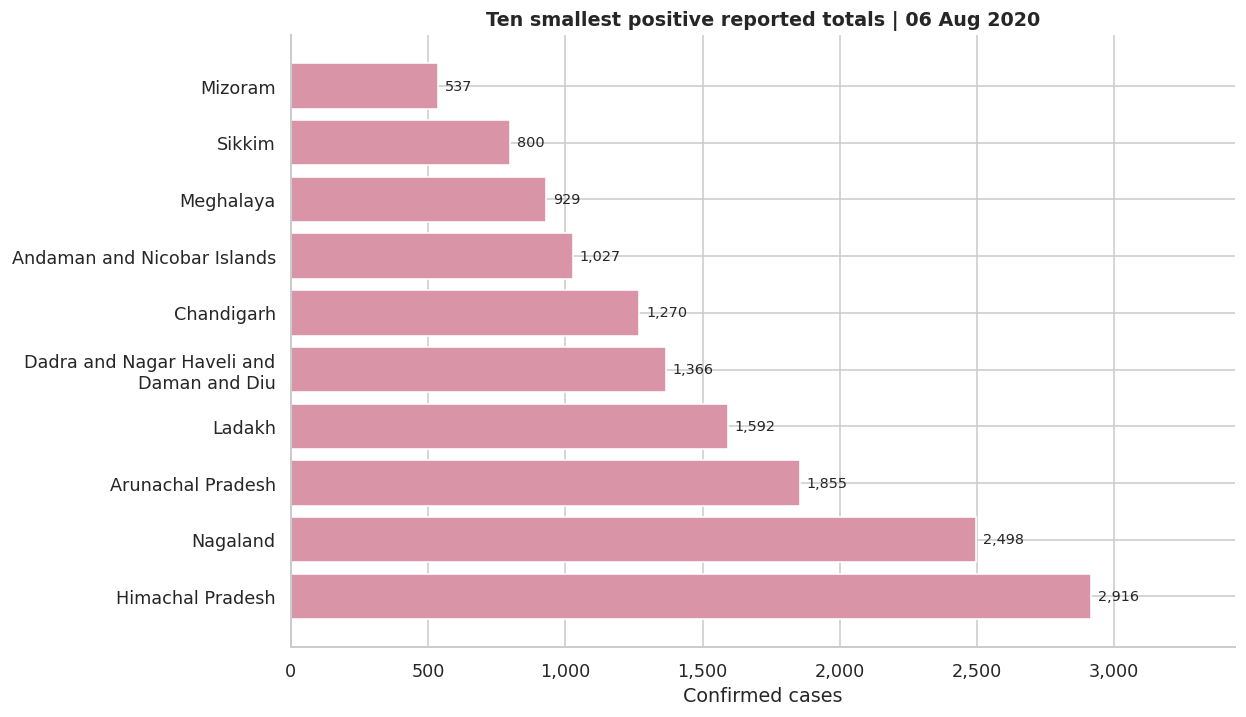

In [31]:
fig, ax = plt.subplots(figsize=(11, 6.4))
labels = [fill(name, 30) for name in bottom10.state]
ax.barh(labels, bottom10.confirmed, color="#D994A7")
ax.invert_yaxis()
for y, number in enumerate(bottom10.confirmed):
    ax.text(number+25, y, f"{number:,.0f}", va="center", fontsize=9)
ax.set(xlim=(0, bottom10.confirmed.max()*1.18), xlabel="Confirmed cases", ylabel="",
       title=f"Ten smallest positive reported totals | {latest_date:%d %b %Y}")
count_axis(ax, "x")
finish(fig, "12_low_case_states")
smallest = bottom10.iloc[0]

In [32]:
observe(f"{smallest.state} has the smallest positive count in this snapshot ({smallest.confirmed:,.0f}). "
        "The comparison includes only states/UTs present in the file and does not treat an absent territory as having zero cases. Population-adjusted comparisons would require additional data.")

**Observation.** Mizoram has the smallest positive count in this snapshot (537). The comparison includes only states/UTs present in the file and does not treat an absent territory as having zero cases. Population-adjusted comparisons would require additional data.

### 13 · State/month pivot as a heatmap

How large are the last available monthly cumulative totals for the five leading states?

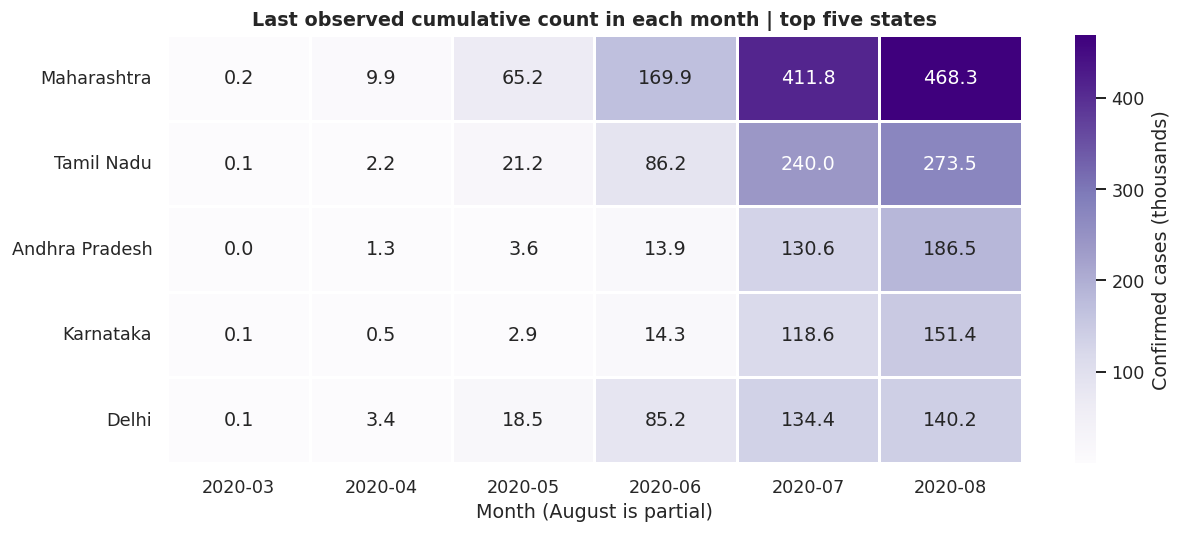

In [33]:
fig, ax = plt.subplots(figsize=(11, 4.8))
sns.heatmap(month_pivot/1000, annot=True, fmt=".1f", cmap="Purples", linewidths=.8,
            cbar_kws={"label": "Confirmed cases (thousands)"}, ax=ax)
ax.set(title="Last observed cumulative count in each month | top five states", xlabel="Month (August is partial)", ylabel="")
ax.tick_params(axis="x", rotation=0); ax.tick_params(axis="y", rotation=0)
finish(fig, "13_monthly_pivot")

In [34]:
observe(f"For {leader.state}, the last observed July count is {month_pivot.loc[leader.state, '2020-07']:,.0f}, "
        f"rising to {month_pivot.loc[leader.state, '2020-08']:,.0f} in the partial August column. "
        "Cells are cumulative snapshots, not monthly new cases. Blank cells mean no available state/month observation, not zero cases.")

**Observation.** For Maharashtra, the last observed July count is 411,798, rising to 468,265 in the partial August column. Cells are cumulative snapshots, not monthly new cases. Blank cells mean no available state/month observation, not zero cases.

## 8. Written report and conclusion

In [35]:
report = f"""# COVID-19 India EDA — Written Report

Prepared for: Sanchita Senapati

## Objective and scope
This project uses NumPy, Pandas, Matplotlib and Seaborn to explore historical Indian COVID-19 reporting. It covers {len(cases):,} case rows, {cases.state.nunique()} standardised state/UT labels and {cases.date.nunique()} observed dates between {cases.date.min():%d %B %Y} and {latest_date:%d %B %Y}. Vaccination data is analysed separately from {vax.date.min():%d %B %Y} to {vax.date.max():%d %B %Y}. Thirteen visualisations cover national trends, state comparisons, rates, monthly summaries and vaccination.

## Method
Raw files were inspected for types, nulls and duplicates. Cleaning standardised state labels and removed a visible numeric footnote marker without inventing missing observations. Active cases and cumulative recovery/fatality percentages were derived. Pandas groupby aggregated reported national counts; a pivot table summarised last observed monthly state totals. Rankings used one common date. Daily comparisons required consecutive dates, identical reporting-state sets and no negative confirmed corrections.

## Findings
- The final case snapshot contains **{last.confirmed:,.0f} confirmed cases**, **{last.recovered:,.0f} recovered/discharged/migrated records**, **{last.deaths:,.0f} deaths** and an **active residual of {last.active:,.0f}**.
- The national cumulative recovery ratio is **{last.recovery_pct:.2f}%** and the reported case-fatality ratio is **{last.fatality_pct:.2f}%**.
- **{leader.state}** has the largest absolute count, accounting for **{leader.confirmed/last.confirmed*100:.1f}%** of cases. The top six states together contribute **{top6_share:.1f}%**.
- Among the ten highest-count states, the recovery ratio ranges from **{lowest_recovery.recovery_pct:.1f}% in {lowest_recovery.state}** to **{best_recovery.recovery_pct:.1f}% in {best_recovery.state}**.
- The greatest retained comparable daily increase is **{daily.loc[valid_peak_date, 'daily_change']:,.0f} on {valid_peak_date:%d %B %Y}**. The raw apparent peak of **{national.loc[jump_date, 'raw_change']:,.0f}** coincides with changing state coverage and should not be interpreted as a genuine one-day infection peak.
- Later vaccination records reach **{last_doses.total_vaccinations/1e9:.3f} billion administered doses** and **{last_fully.people_fully_vaccinated/1e6:.1f} million fully vaccinated people**, with the separate metric dates documented under Chart 11.

## Limitations
There are {len(missing_dates)} entirely missing calendar dates and {len(revision_rows)} state/date rows with a negative change in at least one cumulative metric. Reporting-state coverage also changes. Even matched-coverage days may contain reporting delays or unverified revisions. Counts are not adjusted for population or testing. Recovery and fatality percentages are crude cumulative ratios with timing and denominator limitations. The recovered field also includes discharged/migrated records. The vaccination series is national, has missing values, and occurs after the case window. Correlations among cumulative quantities do not prove causation. August 2020 is a partial month, and no claim is made about the complete first-wave peak or present-day COVID-19 conditions.

## Conclusion
The observed outbreak grew substantially during this early reporting window, with large absolute counts concentrated in a small group of states. Recovery ratios differed across states, while daily reporting comparisons were sensitive to missing dates and changes in geographic coverage. The later vaccination data describes a large rollout but cannot explain movements in the earlier case series. The central lesson is that useful EDA requires both clear visualisation and checks on how the underlying records were assembled.
"""
display(Markdown(report))

# COVID-19 India EDA — Written Report

Prepared for: Sanchita Senapati

## Objective and scope
This project uses NumPy, Pandas, Matplotlib and Seaborn to explore historical Indian COVID-19 reporting. It covers 4,692 case rows, 35 standardised state/UT labels and 186 observed dates between 30 January 2020 and 06 August 2020. Vaccination data is analysed separately from 15 January 2021 to 12 August 2024. Thirteen visualisations cover national trends, state comparisons, rates, monthly summaries and vaccination.

## Method
Raw files were inspected for types, nulls and duplicates. Cleaning standardised state labels and removed a visible numeric footnote marker without inventing missing observations. Active cases and cumulative recovery/fatality percentages were derived. Pandas groupby aggregated reported national counts; a pivot table summarised last observed monthly state totals. Rankings used one common date. Daily comparisons required consecutive dates, identical reporting-state sets and no negative confirmed corrections.

## Findings
- The final case snapshot contains **1,964,536 confirmed cases**, **1,328,336 recovered/discharged/migrated records**, **40,699 deaths** and an **active residual of 595,501**.
- The national cumulative recovery ratio is **67.62%** and the reported case-fatality ratio is **2.07%**.
- **Maharashtra** has the largest absolute count, accounting for **23.8%** of cases. The top six states together contribute **67.4%**.
- Among the ten highest-count states, the recovery ratio ranges from **49.3% in Karnataka** to **89.9% in Delhi**.
- The greatest retained comparable daily increase is **70,962 on 18 July 2020**. The raw apparent peak of **106,421** coincides with changing state coverage and should not be interpreted as a genuine one-day infection peak.
- Later vaccination records reach **2.207 billion administered doses** and **952.0 million fully vaccinated people**, with the separate metric dates documented under Chart 11.

## Limitations
There are 4 entirely missing calendar dates and 9 state/date rows with a negative change in at least one cumulative metric. Reporting-state coverage also changes. Even matched-coverage days may contain reporting delays or unverified revisions. Counts are not adjusted for population or testing. Recovery and fatality percentages are crude cumulative ratios with timing and denominator limitations. The recovered field also includes discharged/migrated records. The vaccination series is national, has missing values, and occurs after the case window. Correlations among cumulative quantities do not prove causation. August 2020 is a partial month, and no claim is made about the complete first-wave peak or present-day COVID-19 conditions.

## Conclusion
The observed outbreak grew substantially during this early reporting window, with large absolute counts concentrated in a small group of states. Recovery ratios differed across states, while daily reporting comparisons were sensitive to missing dates and changes in geographic coverage. The later vaccination data describes a large rollout but cannot explain movements in the earlier case series. The central lesson is that useful EDA requires both clear visualisation and checks on how the underlying records were assembled.


## 9. Export the cleaned data and report

Exports retain reporting-quality flags and unresolved missing vaccination values. Missing first differences are expected: there is no prior observation for the first record of each state.

In [36]:
cases.to_csv(OUTPUT / "cleaned_covid_india.csv", index=False)
vax.to_csv(OUTPUT / "cleaned_vaccination_india.csv", index=False)
national.to_csv(OUTPUT / "national_summary.csv", index_label="date")
latest.to_csv(OUTPUT / "latest_state_snapshot.csv", index=False)
month_pivot.to_csv(OUTPUT / "state_month_pivot.csv")
quality.to_csv(OUTPUT / "data_quality_summary.csv", index=False)
revision_rows.to_csv(OUTPUT / "reporting_revisions.csv", index=False)
(OUTPUT / "REPORT.md").write_text(report + "\n\n## Chart observations\n\n" +
                                  "\n\n".join(f"{i+1}. {text}" for i, text in enumerate(observations)), encoding="utf-8")

# Meaningful validation of the delivered outputs.
assert not cases.duplicated(["date", "state"]).any()
assert np.isclose(latest.confirmed.sum(), last.confirmed)
assert np.isclose(last.active + last.recovered + last.deaths, last.confirmed)
assert np.isclose(shares.sum(), last.confirmed)
assert national.loc[national.comparable_day, "same_states"].all()
assert len(list(FIGURES.glob("*.png"))) == 13
for path in sorted(OUTPUT.glob("*")):
    if path.is_file():
        print(path.relative_to(BASE))
print("Validation passed. Thirteen chart images and cleaned tables exported.")

outputs/REPORT.md
outputs/cleaned_covid_india.csv
outputs/cleaned_vaccination_india.csv
outputs/data_quality_summary.csv
outputs/latest_state_snapshot.csv
outputs/national_summary.csv
outputs/reporting_revisions.csv
outputs/state_month_pivot.csv
Validation passed. Thirteen chart images and cleaned tables exported.


## 10. Explain it in a viva

- **Why EDA?** It helps identify distributions, trends, relationships and quality problems before attempting modelling.
- **Why `groupby()`?** It combines state rows for each reporting date using an explicit aggregation.
- **Why not sum cumulative values across dates?** The same underlying cases appear again in later totals.
- **Why use `pivot_table()`?** It reshapes state/month summaries into a readable comparison grid.
- **Why preserve missing values?** Missing reporting is different from a real count of zero.
- **Why check the reporting states?** A returning state can add its accumulated total, producing a false daily spike.
- **Why avoid a vaccine-effect claim?** These case observations end before the vaccination series begins, so the datasets cannot support that inference.

## References and attribution

1. Supplied *India COVID-19 EDA Mini-Project* PDF: project requirements and chart coverage.
2. [Training notebook by aamir-gk2539-byte](https://github.com/aamir-gk2539-byte/DSML-Training/blob/main/MiniProject_COVID19_India_EDA.ipynb): scope reference; no chart outputs or report text were reused.
3. [imdevskp/covid-19-india-data](https://github.com/imdevskp/covid-19-india-data): raw case dataset; the upstream project documents its source compilation.
4. [Our World in Data COVID-19 vaccination data](https://github.com/owid/covid-19-data/tree/master/public/data/vaccinations): raw national vaccination series; individual source URLs are retained in the CSV.

Raw datasets retain their original provenance and applicable upstream terms. Retrieval was on 24 September 2026; source commits are pinned in the loading cell and documented with checksums in the project bundle.